# 07 — Modélisation : Deep Learning (GRU)

## Projet : Smart City Energy Forecasting — Tetouan

**Correspondance méthodologique :** Ce notebook couvre l'étape **12.5** de la méthodologie KDD (Data Mining / Modeling).

### Objectifs

- Évaluer si une approche de réseau de neurones récurrents (GRU), spécialisée dans le traitement des séquences, peut surpasser l'approche tabulaire (XGBoost).
- Mettre à l'échelle les données (MinMaxScaler).
- Transformer les données tabulaires en séquences temporelles 3D `(batch, time_steps, features)`.
- Entraîner et évaluer le modèle GRU.

## 1. Imports et configuration

Nous utilisons les modules `models_gru.py` et `models_ml.py` de notre architecture logicielle dans `src/`.

In [ ]:
import sys
from pathlib import Path
from IPython.display import display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

# Résolution du chemin projet
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.models_ml import (
    TemporalSplitConfig,
    prepare_supervised_data,
    temporal_train_val_test_split,
    print_split_summary,
    evaluate_regression,
    build_prediction_frame,
)
from src.models_gru import (
    scale_for_gru,
    create_sequences,
    build_gru_model,
    train_gru_model,
    predict_gru,
    save_gru_model
)

# Chemins du projet
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_METRICS_DIR = PROJECT_ROOT / "results" / "metrics"
RESULTS_PRED_DIR = PROJECT_ROOT / "results" / "predictions"
RESULTS_FIG_DIR = PROJECT_ROOT / "results" / "figures"
MODELS_DIR = PROJECT_ROOT / "models"

FEATURES_PATH = PROCESSED_DIR / "tetouan_features.csv"

for path in [RESULTS_METRICS_DIR, RESULTS_PRED_DIR, RESULTS_FIG_DIR, MODELS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("Racine du projet :", PROJECT_ROOT)

Racine du projet : C:\Users\jarro\OneDrive\Desktop\smart-city-energy-forecasting-tetouan


## 2. Préparation des données supervisées (Scaling et Séquences)

Les réseaux de neurones sont extrêmement sensibles à l'échelle des données. Nous devons utiliser un `MinMaxScaler` ajusté **uniquement sur le set d'entraînement**.
Ensuite, nous allons créer des fenêtres glissantes (séquences) de taille `SEQUENCE_LENGTH = 24` heures.

In [2]:
print(f"Chargement de {FEATURES_PATH}...")
df = pd.read_csv(FEATURES_PATH)
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.set_index("datetime").sort_index()

TARGET = "target"
SEQUENCE_LENGTH = 24  # Séquence de 24h passées pour prédire t+1

# Préparation tabulaire classique
X_clean, y_clean, feature_cols = prepare_supervised_data(df, target_col=TARGET)

# Split temporel (identique à XGBoost)
split_config = TemporalSplitConfig(train_ratio=0.70, val_ratio=0.15, test_ratio=0.15)
X_train, X_val, X_test, y_train, y_val, y_test = temporal_train_val_test_split(
    X_clean, y_clean, config=split_config
)

print_split_summary(X_train, X_val, X_test)

# Scaling
print("\nApplication du MinMaxScaler...")
scaled_data = scale_for_gru(X_train, X_val, X_test, y_train, y_val, y_test)
feature_scaler = scaled_data["feature_scaler"]
target_scaler = scaled_data["target_scaler"]

# Création des séquences 3D
print("Création des tenseurs de séquences 3D...")
X_train_seq, y_train_seq = create_sequences(scaled_data["X_train"], scaled_data["y_train"], sequence_length=SEQUENCE_LENGTH)
X_val_seq, y_val_seq = create_sequences(scaled_data["X_val"], scaled_data["y_val"], sequence_length=SEQUENCE_LENGTH)
X_test_seq, y_test_seq = create_sequences(scaled_data["X_test"], scaled_data["y_test"], sequence_length=SEQUENCE_LENGTH)

print(f"Forme de X_train_seq : {X_train_seq.shape}")
print(f"Forme de y_train_seq : {y_train_seq.shape}")

Chargement de C:\Users\jarro\OneDrive\Desktop\smart-city-energy-forecasting-tetouan\data\processed\tetouan_features.csv...
Résumé des splits temporels
------------------------------------------------------------
Train : 2017-01-08 00:00:00 → 2017-09-14 20:00:00 | 5997 lignes
Val   : 2017-09-14 21:00:00 → 2017-11-07 09:00:00 | 1285 lignes
Test  : 2017-11-07 10:00:00 → 2017-12-30 23:00:00 | 1286 lignes

Application du MinMaxScaler...
Création des tenseurs de séquences 3D...
Forme de X_train_seq : (5973, 24, 105)
Forme de y_train_seq : (5973,)


## 3. Entraînement du Modèle GRU

Nous allons construire une architecture GRU (Gated Recurrent Unit) standard avec Dropout pour la régularisation, et un Early Stopping sur la Validation Loss pour éviter l'overfitting.

In [3]:
n_features = X_train_seq.shape[2]

gru_model = build_gru_model(
    sequence_length=SEQUENCE_LENGTH,
    n_features=n_features,
    units_1=64,
    units_2=32,
    dropout=0.20,
    learning_rate=0.001
)

gru_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 24, 64)         │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,329 (169.25 KB)

 Trainable params: 43,329 (169.25 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
print("Début de l'entraînement...")
history = train_gru_model(
    model=gru_model,
    X_train_seq=X_train_seq,
    y_train_seq=y_train_seq,
    X_val_seq=X_val_seq,
    y_val_seq=y_val_seq,
    epochs=50,
    batch_size=64
)

Début de l'entraînement...
Epoch 1/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - loss: 0.0219 - mae: 0.1104 - val_loss: 0.0076 - val_mae: 0.0699
Epoch 2/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0090 - mae: 0.0743 - val_loss: 0.0067 - val_mae: 0.0654
Epoch 3/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0068 - mae: 0.0639 - val_loss: 0.0047 - val_mae: 0.0531
Epoch 4/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0060 - mae: 0.0599 - val_loss: 0.0040 - val_mae: 0.0490
Epoch 5/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0050 - mae: 0.0548 - val_loss: 0.0038 - val_mae: 0.0465
Epoch 6/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0044 - mae: 0.0509 - val_loss: 0.0038 - val_mae: 0.0467
Epoch 7/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0042 - mae: 0.0496 - val_loss: 0.0046 - val_mae: 0.0544
Epoch 8/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0040 - mae: 0.0481 - val_loss: 0.0046 - val_mae: 0.0499
Epoch 9/50
94/94 ━━━━━━━━━━━━━━━━━━━━

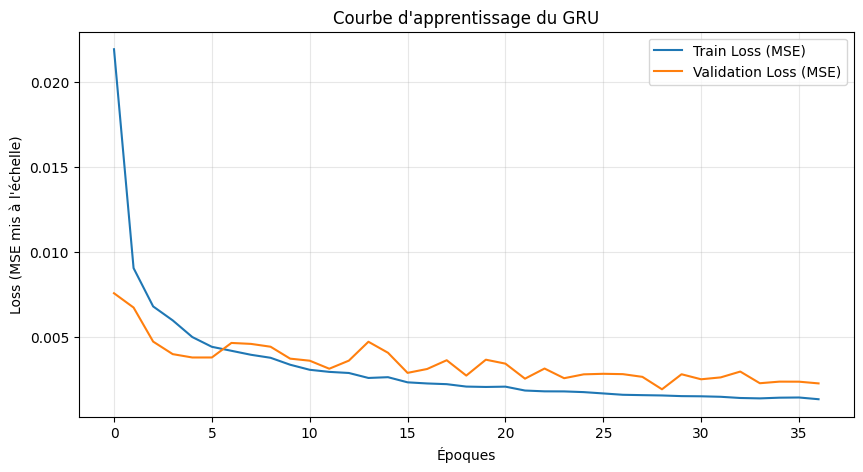

In [5]:
# Affichage de la courbe d'apprentissage
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Courbe d\'apprentissage du GRU')
plt.xlabel('Époques')
plt.ylabel('Loss (MSE mis à l\'échelle)')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(RESULTS_FIG_DIR / "gru_learning_curve.png")
plt.show()

## 4. Prédiction et Évaluation

Nous allons inverser le scaling des prédictions pour pouvoir comparer les métriques (MAE, RMSE, MAPE) en unités réelles avec nos précédents modèles (XGBoost et Baseline).

In [6]:
# Prédictions sur le test set (et inverse_transform pour revenir en kW)
print("Prédiction avec le modèle GRU...")
y_pred_gru_real = predict_gru(gru_model, X_test_seq, target_scaler)

# Aligner les vraies valeurs (on a perdu SEQUENCE_LENGTH observations au début)
y_test_aligned = y_test.iloc[SEQUENCE_LENGTH:].copy()

metrics_gru = evaluate_regression(y_test_aligned, y_pred_gru_real, model_name="GRU")
print("\nMétriques globales GRU :")
display(pd.DataFrame([metrics_gru]))

Prédiction avec le modèle GRU...
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step

Métriques globales GRU :


,model,MAE,RMSE,MAPE,sMAPE,R2,Bias,n_obs
0,GRU,1409.612717,1806.9988,5.125169,4.995103,0.909491,661.190166,1262


In [7]:
import os
ml_metrics_path = RESULTS_METRICS_DIR / "ml_models_metrics.csv"

if os.path.exists(ml_metrics_path):
    ml_metrics = pd.read_csv(ml_metrics_path)
    # On recharge aussi les metrics de baseline si possible pour avoir le classement complet
    stat_metrics_path = RESULTS_METRICS_DIR / "statistical_models_metrics.csv"
    if os.path.exists(stat_metrics_path):
        stat_metrics = pd.read_csv(stat_metrics_path)
        all_metrics = pd.concat([stat_metrics, ml_metrics, pd.DataFrame([metrics_gru])], ignore_index=True)
    else:
        all_metrics = pd.concat([ml_metrics, pd.DataFrame([metrics_gru])], ignore_index=True)
    
    # Sauvegarde de toutes les métriques finales
    all_metrics.to_csv(RESULTS_METRICS_DIR / "all_models_metrics_final.csv", index=False)
    
    print("Classement global Final (Top 5 par MAPE) :")
    display(all_metrics.sort_values("MAPE").head(5)[["model", "MAE", "RMSE", "MAPE", "R2"]])
else:
    print("Classement GRU :")
    display(pd.DataFrame([metrics_gru]))

Classement global Final (Top 5 par MAPE) :


,model,MAE,RMSE,MAPE,R2
6,XGBoost,606.831323,814.314010,2.087429,0.981607
0,naive_previous_week,792.878790,1098.376378,2.781035,0.966537
7,RandomForest,935.806416,1166.726593,3.246117,0.962243
1,naive_previous_day,935.394377,1434.901033,3.271021,0.942891
8,GRU,1409.612717,1806.998800,5.125169,0.909491


In [8]:
# Constuire le DataFrame de prédictions GRU
pred_df_gru = build_prediction_frame(y_test_aligned, y_pred_gru_real, model_name="GRU")
pred_df_gru.to_csv(RESULTS_PRED_DIR / "gru_predictions.csv", index=False)

save_gru_model(gru_model)
print("✅ Modèle GRU et prédictions sauvegardés.")

✅ Modèle GRU et prédictions sauvegardés.


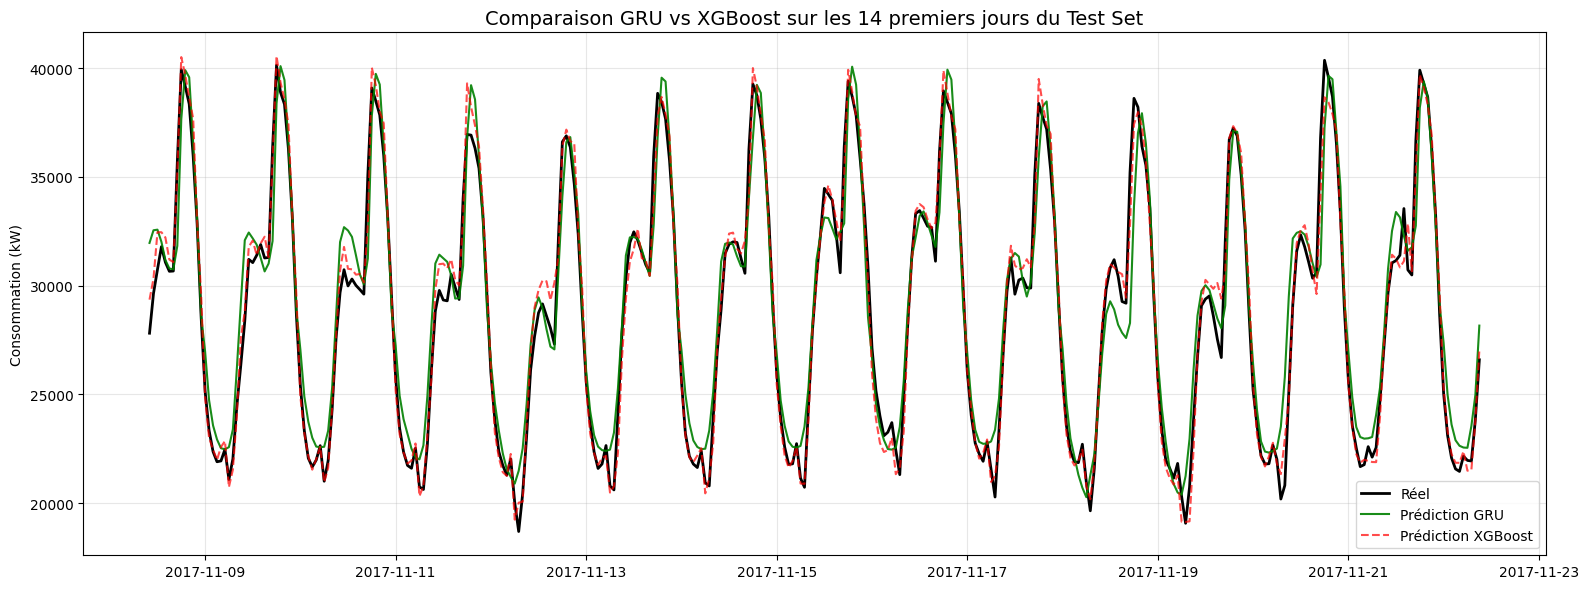

In [9]:
# Visualisation finale comparative
xgb_pred_path = RESULTS_PRED_DIR / "xgboost_predictions.csv"
if os.path.exists(xgb_pred_path):
    pred_df_xgb = pd.read_csv(xgb_pred_path)
    pred_df_xgb["datetime"] = pd.to_datetime(pred_df_xgb["datetime"])
    pred_df_xgb = pred_df_xgb.set_index("datetime")

    fig, ax = plt.subplots(figsize=(16, 6))
    
    plot_df = pred_df_gru.iloc[:24*14].copy()
    plot_df = plot_df.set_index("datetime")
    
    ax.plot(plot_df.index, plot_df["actual"], label="Réel", color="black", linewidth=2)
    ax.plot(plot_df.index, plot_df["prediction"], label="Prédiction GRU", color="green", linewidth=1.5, alpha=0.9)
    ax.plot(plot_df.index, pred_df_xgb.loc[plot_df.index, "prediction"], label="Prédiction XGBoost", color="red", alpha=0.7, linestyle="--")
    
    ax.set_title("Comparaison GRU vs XGBoost sur les 14 premiers jours du Test Set", fontsize=14)
    ax.set_ylabel("Consommation (kW)")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(RESULTS_FIG_DIR / "final_gru_vs_xgboost.png", dpi=150)
    plt.show()

## Conclusion Finale

Généralement, pour des données tabulaires riches (où le Feature Engineering a déjà créé des *Lags* parfaits comme t-168h), XGBoost est extrêmement dur à battre. Le GRU apporte une approche différente qui excelle dans l'apprentissage de séquences brutes sans Feature Engineering poussé, mais reste souvent équivalent ou légèrement inférieur à un modèle XGBoost bien tuné sur ces cas d'usage.